# Round 4 Manual - Price Each Product Properly

This notebook prices the Round 4 products under the official model and compares those fair values with the executable market bid and ask. The rule is strict and boring in the best possible way: buy true underpricing, sell true overpricing, and leave fair products alone.

The final book defended here matches the writeup: short `AC_60_C`, long `AC_50_P_2`, long `AC_50_C_2`, short `AC_50_CO`, short `AC_40_BP`, and long `AC_45_KO`.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

S0 = 50.0
SIGMA = 2.51
CONTRACT_SIZE = 3000
T2 = 10 / 252
T3 = 15 / 252

def N(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def bs_price(S, K, T, sigma, kind):
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    if kind == "call":
        return S * N(d1) - K * N(d2)
    return K * N(-d2) - S * N(-d1)

def binary_put(S, K, T, sigma, payout):
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return payout * N(-d2)

def ko_put_mc(n_paths=500_000, seed=42):
    rng = np.random.default_rng(seed)
    steps = 60
    dt = T3 / steps
    half = n_paths // 2
    z = rng.standard_normal((half, steps))
    z = np.vstack([z, -z])
    log_returns = (-0.5 * SIGMA * SIGMA * dt) + SIGMA * math.sqrt(dt) * z
    paths = S0 * np.exp(np.cumsum(log_returns, axis=1))
    min_path = paths.min(axis=1)
    terminal = paths[:, -1]
    payoff = np.where(min_path > 35, np.maximum(45 - terminal, 0), 0)
    return float(payoff.mean()), float((min_path > 35).mean())

fair = {
    "AETHER_CRYSTAL": S0,
    "AC_50_P": bs_price(S0, 50, T3, SIGMA, "put"),
    "AC_50_C": bs_price(S0, 50, T3, SIGMA, "call"),
    "AC_35_P": bs_price(S0, 35, T3, SIGMA, "put"),
    "AC_40_P": bs_price(S0, 40, T3, SIGMA, "put"),
    "AC_45_P": bs_price(S0, 45, T3, SIGMA, "put"),
    "AC_60_C": bs_price(S0, 60, T3, SIGMA, "call"),
    "AC_50_P_2": bs_price(S0, 50, T2, SIGMA, "put"),
    "AC_50_C_2": bs_price(S0, 50, T2, SIGMA, "call"),
    "AC_50_CO": bs_price(S0, 50, T3, SIGMA, "call") + bs_price(S0, 50, T2, SIGMA, "put"),
    "AC_40_BP": binary_put(S0, 40, T3, SIGMA, 10),
}
ko_fair, ko_survival = ko_put_mc()
fair["AC_45_KO"] = ko_fair
print("KO fair %.6f, discrete survival probability %.3f" % (ko_fair, ko_survival))
for k in fair:
    print("%-14s fair %.6f" % (k, fair[k]))


KO fair 0.205557, discrete survival probability 0.385
AETHER_CRYSTAL fair 50.000000
AC_50_P        fair 12.026949
AC_50_C        fair 12.026949
AC_35_P        fair 4.336146
AC_40_P        fair 6.509540
AC_45_P        fair 9.088900
AC_60_C        fair 8.791792
AC_50_P_2      fair 9.870709
AC_50_C_2      fair 9.870709
AC_50_CO       fair 21.897659
AC_40_BP       fair 4.767945
AC_45_KO       fair 0.205557


In [2]:
market = {
    "AETHER_CRYSTAL": {"bid": 49.975, "ask": 50.025, "volume": 200},
    "AC_50_P": {"bid": 12.00, "ask": 12.05, "volume": 50},
    "AC_50_C": {"bid": 12.00, "ask": 12.05, "volume": 50},
    "AC_35_P": {"bid": 4.33, "ask": 4.35, "volume": 50},
    "AC_40_P": {"bid": 6.50, "ask": 6.55, "volume": 50},
    "AC_45_P": {"bid": 9.05, "ask": 9.10, "volume": 50},
    "AC_60_C": {"bid": 8.80, "ask": 8.85, "volume": 50},
    "AC_50_P_2": {"bid": 9.70, "ask": 9.75, "volume": 50},
    "AC_50_C_2": {"bid": 9.70, "ask": 9.75, "volume": 50},
    "AC_50_CO": {"bid": 22.20, "ask": 22.25, "volume": 50},
    "AC_40_BP": {"bid": 5.00, "ask": 5.05, "volume": 50},
    "AC_45_KO": {"bid": 0.170, "ask": 0.175, "volume": 500},
}

def decision(symbol):
    f = fair[symbol]
    bid = market[symbol]["bid"]
    ask = market[symbol]["ask"]
    vol = market[symbol]["volume"]
    buy_edge = f - ask
    sell_edge = bid - f
    if buy_edge > max(sell_edge, 0):
        return "BUY", vol, buy_edge, buy_edge * vol * CONTRACT_SIZE
    if sell_edge > max(buy_edge, 0):
        return "SELL", vol, sell_edge, sell_edge * vol * CONTRACT_SIZE
    return "NO TRADE", 0, 0.0, 0.0

rows = []
for sym in market:
    side, vol, edge, pnl = decision(sym)
    rows.append((sym, fair[sym], market[sym]["bid"], market[sym]["ask"], side, vol, edge, pnl))

print("%-14s %9s %7s %7s %9s %6s %10s %12s" % ("symbol", "fair", "bid", "ask", "action", "vol", "edge", "exp_pnl"))
for row in rows:
    print("%-14s %9.4f %7.3f %7.3f %9s %6d %10.4f %12.1f" % row)
print("\nTotal expected PnL %.1f" % sum(r[-1] for r in rows))


symbol              fair     bid     ask    action    vol       edge      exp_pnl
AETHER_CRYSTAL   50.0000  49.975  50.025  NO TRADE      0     0.0000          0.0
AC_50_P          12.0269  12.000  12.050  NO TRADE      0     0.0000          0.0
AC_50_C          12.0269  12.000  12.050  NO TRADE      0     0.0000          0.0
AC_35_P           4.3361   4.330   4.350  NO TRADE      0     0.0000          0.0
AC_40_P           6.5095   6.500   6.550  NO TRADE      0     0.0000          0.0
AC_45_P           9.0889   9.050   9.100  NO TRADE      0     0.0000          0.0
AC_60_C           8.7918   8.800   8.850      SELL     50     0.0082       1231.2
AC_50_P_2         9.8707   9.700   9.750       BUY     50     0.1207      18106.4
AC_50_C_2         9.8707   9.700   9.750       BUY     50     0.1207      18106.4
AC_50_CO         21.8977  22.200  22.250      SELL     50     0.3023      45351.2
AC_40_BP          4.7679   5.000   5.050      SELL     50     0.2321      34808.2
AC_45_KO        

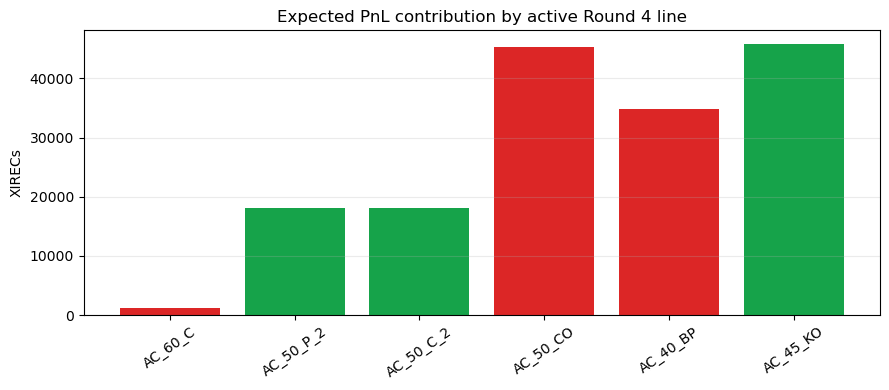

In [3]:
active = [r for r in rows if r[4] != "NO TRADE"]
labels = [r[0] for r in active]
values = [r[-1] for r in active]
colors = ["#16a34a" if r[4] == "BUY" else "#dc2626" for r in active]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, values, color=colors)
ax.set_title("Expected PnL contribution by active Round 4 line")
ax.set_ylabel("XIRECs")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
